In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

cuda


# Dataset

In [2]:
class RawFeatureDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.df = df.copy()
        self.df['deceptive'] = self.df['deceptive'].astype(int)
        self.feature_cols = feature_cols
        self.sample_ids = self.df['id'].unique().tolist()

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        subset = self.df[self.df['id'] == sample_id]
        X = subset[self.feature_cols].values.astype(np.float32)
        y = subset['deceptive'].iloc[0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
    
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = [len(seq) for seq in sequences]
    padded_sequences = nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=-10.0)
    return padded_sequences, torch.tensor(lengths), torch.tensor(labels, dtype=torch.float32)

In [3]:
class FeatureEngineeredDataset(Dataset):
    def __init__(self, df, 
                 raw_cols=[],
                 use_distances=True,
                 use_lm_velocity=False,
                 use_box_velocity=False,
                 zero_center=True,
                 dist_scale=100.0,
                 velocity_scale=100.0,
                 noise_level=0.0):
        
        self.df = df.copy()
        self.sample_ids = self.df['id'].unique().tolist()
        self.df['deceptive'] = self.df['deceptive'].astype(int)

        self.raw_cols = raw_cols
        self.use_distances = use_distances
        self.use_lm_velocity = use_lm_velocity
        self.use_box_velocity = use_box_velocity
        self.zero_center = zero_center
        self.dist_scale = dist_scale
        self.velocity_scale = velocity_scale
        self.noise_level = noise_level
        
        self.box_cols = ['box_center_x', 'box_center_y', 'box_width']
        self.pose_cols = ['head_pitch', 'head_yaw', 'head_roll']
        self.smooth_cols = self.box_cols + self.pose_cols

        for col in self.smooth_cols:
            if col in self.df.columns:
                self.df[col] = self.df.groupby('id')[col].transform(
                    lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
                )
        
        # vertical face height
        self.FACE_TOP = 10
        self.FACE_BOTTOM = 152
        # facial landmark indices
        self.LIPS_V = [13, 14]      # Mouth open/close
        self.LIPS_H = [61, 291]     # Mouth widen/pucker
        self.EYE_L = [159, 145]     # Left Eye blink
        self.EYE_R = [386, 374]     # Right Eye blink
        self.BROW_L = [65, 159]     # Left Brow raise
        self.BROW_R = [295, 386]    # Right Brow raise


    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        subset = self.df[self.df['id'] == sample_id].reset_index(drop=True)
        features_list = []

        if self.raw_cols:
            raw = subset[self.raw_cols].values.astype(np.float32)
            raw = np.nan_to_num(raw, nan=0.0)
            features_list.append(raw)

        if self.use_distances or self.use_velocity:
            landmark_data = subset.filter(regex='^lm_').values.astype(np.float32)

            sequence_length = len(subset)
            num_landmarks = landmark_data.shape[1] // 2

            try:
                landmarks = landmark_data.reshape(sequence_length, num_landmarks, 2)
            except ValueError:
                expected_size = (11 if self.use_raw else 0) + (6 if self.use_distances else 0) + (6 if self.use_velocity else 0)
                return torch.zeros((sequence_length, expected_size), dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)

            face_height = np.linalg.norm(landmarks[:, self.FACE_TOP] - landmarks[:, self.FACE_BOTTOM], axis=1)
            face_height = np.clip(face_height, 1e-6, None)

            def get_dist(idx1, idx2):
                return np.linalg.norm(landmarks[:, idx1] - landmarks[:, idx2], axis=1) / face_height
        
            dist_features = np.stack([
                get_dist(self.LIPS_V[0], self.LIPS_V[1]),
                get_dist(self.LIPS_H[0], self.LIPS_H[1]),
                get_dist(self.EYE_L[0], self.EYE_L[1]),
                get_dist(self.EYE_R[0], self.EYE_R[1]),
                get_dist(self.BROW_L[0], self.BROW_L[1]),
                get_dist(self.BROW_R[0], self.BROW_R[1])
            ], axis=1)

            if self.zero_center: 
                dist_features = dist_features - np.mean(dist_features, axis=0)

            if self.use_distances:
                features_list.append(dist_features * self.dist_scale)
            
            if self.use_lm_velocity:
                velocity = np.diff(dist_features, axis=0, prepend=dist_features[:1])
                features_list.append(velocity * self.velocity_scale)

        if self.use_box_velocity:
            box_data = subset[self.box_cols].values.astype(np.float32)
            box_data = np.nan_to_num(box_data, nan=0.0)
            box_velocity = np.diff(box_data, axis=0, prepend=box_data[:1])
            features_list.append(box_velocity * self.velocity_scale)

        X = np.concatenate(features_list, axis=1)
        if self.noise_level > 0.0:
            noise = np.random.normal(0, self.noise_level, X.shape).astype(np.float32)
            X += noise

        y = subset['deceptive'].iloc[0]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [4]:
df = pd.read_csv("../processed_data/silesian_deception_dataset/data10fps.csv")
bad_rows = df[df.isna().any(axis=1)]
bad_ids = bad_rows['id'].unique().tolist()
df = df[~df['id'].isin(bad_ids)].reset_index(drop=True)

# samples = df['id'].unique().tolist()
# sample_labels = df.groupby('id')['deceptive'].first().values
# train_samples, test_samples = train_test_split(samples, test_size=0.2, random_state=42, stratify=sample_labels)
# train_df = df[df['id'].isin(train_samples)].copy()
# test_df = df[df['id'].isin(test_samples)].copy()

if 'person_id' not in df.columns:
    raise ValueError("No column 'person_id' in dataframe.")

people = df['person_id'].unique().tolist()

train_people, temp_people = train_test_split(people, test_size=0.20, random_state=42)

val_people, test_people = train_test_split(temp_people, test_size=0.50, random_state=42)

print(f"People in training: {len(train_people)}")
print(f"People in test: {len(test_people)}")
print(f"People in validation: {len(val_people)}")

train_df = df[df['person_id'].isin(train_people)].copy().reset_index(drop=True)
val_df = df[df['person_id'].isin(val_people)].copy().reset_index(drop=True)
test_df = df[df['person_id'].isin(test_people)].copy().reset_index(drop=True)

assert set(train_df['person_id']).isdisjoint(set(val_df['person_id']))
assert set(train_df['person_id']).isdisjoint(set(test_df['person_id']))
assert set(val_df['person_id']).isdisjoint(set(test_df['person_id']))
print("Split is correct: No leakage of people between sets.")

landmarks_cols = [f'lm_{i}' for i in range(468*2)]
flow_cols = ['flow_mean_x', 'flow_mean_y', 'flow_std_x', 'flow_std_y']
emotion_cols = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
head_pose_cols = ['head_pitch', 'head_yaw', 'head_roll']
box_cols = ['box_center_x', 'box_center_y', 'box_width']
all_feature_cols = landmarks_cols + flow_cols + emotion_cols + head_pose_cols + box_cols

scalers = {}
for cols in [flow_cols, emotion_cols, head_pose_cols, box_cols]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_df[cols] = scaler.fit_transform(train_df[cols])
    val_df[cols] = scaler.transform(val_df[cols])
    test_df[cols] = scaler.transform(test_df[cols])
    scalers.update({col: scaler for col in cols})

scalers_output_path = '../model_weights/scalers.joblib'
joblib.dump(scalers, scalers_output_path)
print(f"Scalers saved to {scalers_output_path}")

# train_dataset = RawFeatureDataset(train_df, all_feature_cols)
# test_dataset = RawFeatureDataset(test_df, all_feature_cols)


# labels = train_df.groupby("id")["deceptive"].first().values
# class_sample_count = np.array([len(np.where(labels==0)[0]), len(np.where(labels==1)[0])])
# weight = 1. / class_sample_count
# samples_weight = np.array([weight[int(l)] for l in labels])
# samples_weight = torch.from_numpy(samples_weight).float()
# sampler = WeightedRandomSampler(samples_weight, len(samples_weight))


People in training: 80
People in test: 11
People in validation: 10
Split is correct: No leakage of people between sets.
Scalers saved to ../model_weights/scalers.joblib


In [5]:
raw_cols = flow_cols + emotion_cols + head_pose_cols

train_dataset = FeatureEngineeredDataset(train_df, raw_cols=raw_cols, use_lm_velocity=False, use_box_velocity=True, noise_level=0.05)
val_dataset = FeatureEngineeredDataset(val_df, raw_cols=raw_cols, use_lm_velocity=False, use_box_velocity=True)
test_dataset = FeatureEngineeredDataset(test_df, raw_cols=raw_cols, use_lm_velocity=False, use_box_velocity=True)

train_loader = DataLoader(train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False, drop_last=True)

/tmp/ipykernel_4096/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_4096/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_4096/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()


In [6]:
df['id'].nunique()

924

In [7]:
num_pos_videos = sum([train_dataset[i][1].item() == 1 for i in range(len(train_dataset))])
num_neg_videos = len(train_dataset) - num_pos_videos
pos_weight = torch.tensor(num_neg_videos / num_pos_videos, dtype=torch.float32).to(device)

print(f"Number of positive samples: {num_pos_videos}, Number of negative samples: {num_neg_videos}")

Number of positive samples: 496, Number of negative samples: 233


# BiGRU with attention

In [6]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out, mask):
        scores = self.attn(lstm_out).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e4)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        context = torch.sum(weights * lstm_out, dim=1)
        return context, weights

class BiGRUAttention(nn.Module):
    def __init__(self, input_dim=23, hidden_dim=16, num_layers=2, dropout=0.4):
        super().__init__()

        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        self.attn = Attention(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.GRU) or isinstance(m, nn.LSTM):
            for name, param in m.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_normal_(param.data)
                elif 'weight_hh' in name:
                    nn.init.orthogonal_(param.data)
                elif 'bias' in name:
                    nn.init.zeros_(param.data)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)

        mask = torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None].to(out.device)
        context, weights = self.attn(out, mask)

        logits = self.classifier(context).squeeze(1)
        return logits, weights

In [9]:
def find_best_threshold(y_true, y_probs):
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in np.arange(0.1, 0.91, 0.01):
        preds = (y_probs >= thresh).astype(int)
        score = f1_score(y_true, preds)
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    return best_thresh, best_f1

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for X, lengths, y in loader:
            X, y = X.to(device), y.to(device)
            
            logits, _ = model(X, lengths)
            probs = torch.sigmoid(logits)
            
            preds = (probs > 0.5).float()
            
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = 0.5
    
    best_thresh, best_f1 = find_best_threshold(y_true, y_prob)
    
    best_preds = (y_prob >= best_thresh).astype(int)
    acc_at_best = accuracy_score(y_true, best_preds)
    
    return {"acc": acc, "f1": f1, "auc": auc, "best_thresh": best_thresh, "best_f1": best_f1, "acc_at_best": acc_at_best}

# Training

In [10]:
def train(
        model,
        optimizer, 
        criterion, 
        train_loader, 
        eval_loader, 
        scheduler=None,
        num_epochs=100, 
        early_stop=False,
        early_stop_patience=25,
        save_best_model_path="../model_weights/best_model.pt",
        scorer="auc",
        mode="max",
        load_best_model=False
        ):
    
    history = {
        'train_loss': [],
        'val_auc': [],
        'val_f1': [],
        'val_acc': [],
        'best_thresh': []
    }

    best_score = float('-inf') if mode == 'max' else float('inf')
    epochs_no_improve = 0
    
    is_one_cycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X, lengths, y in train_loader:
            X, lengths, y = X.to(device), lengths.to(device), y.to(device)

            optimizer.zero_grad()

            logits, _ = model(X, lengths)
            loss = criterion(logits, y)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if is_one_cycle and scheduler is not None:
                scheduler.step()
            
            total_loss += loss.item()
        
        train_loss = total_loss / len(train_loader)
        metrics = evaluate(model, eval_loader)
        current_score = metrics[scorer]

        history['train_loss'].append(train_loss)
        history['val_auc'].append(metrics['auc'])
        history['val_f1'].append(metrics['best_f1'])
        history['val_acc'].append(metrics['acc_at_best'])
        history['best_thresh'].append(metrics['best_thresh'])
        
        print(f"Epoch {epoch+1}: Loss={train_loss:.4f} | AUC={metrics['auc']:.4f} | Best F1={metrics['best_f1']:.3f} (Thresh={metrics['best_thresh']:.2f}) | Acc={metrics['acc_at_best']:.3f}")
        if scheduler and not is_one_cycle:
            scheduler.step(current_score)
        
        if (current_score > best_score and mode == "max") or (current_score < best_score and mode == "min"):
            best_score = current_score
            epochs_no_improve = 0

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'threshold': metrics['best_thresh'],
            }

            torch.save(checkpoint, save_best_model_path)
        else:
            epochs_no_improve += 1

            if early_stop and epochs_no_improve >= early_stop_patience:
                print("Early stopping.")
                break

    if load_best_model:
        checkpoint = torch.load(save_best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        return history, checkpoint['threshold']
    
    return history, metrics['best_thresh']

In [18]:
def evaluate_test_set(model, test_loader, device, threshold=0.5, class_names=['Truth', 'Deception'], confusion_matrix_path='../docs/wut-thesis/images/confusion_matrix_test.png'):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    print(f"Evaluating on test set with threshold {threshold}...")
    
    with torch.no_grad():
        for X, lengths, y in test_loader:
            X, lengths, y = X.to(device), lengths.to(device), y.to(device)
            
            outputs = model(X, lengths)[0]

            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > threshold).long()
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    
    print(f"\n=== RESULTS ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC ROC:   {auc:.4f}")
    print("-" * 30)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Prawdziwa Etykieta')
    plt.xlabel('Przewidywana Etykieta')
    plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return all_labels, all_probs

In [20]:
def plot_learning_curves(history, save_dir="../docs/wut-thesis/images/"):
    os.makedirs(save_dir, exist_ok=True)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.style.use('ggplot')

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Strata treningowa')
    
    # plt.title('Przebieg funkcji straty w procesie uczenia', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('Wartość straty (Loss)', fontsize=12)
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "loss_curve.png"), dpi=300)
    plt.close()
    print(f"Zapisano: {os.path.join(save_dir, 'loss_curve.png')}")

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, history['val_auc'], 'r-', linewidth=2, label='Walidacyjne AUC')
    plt.plot(epochs, history['val_f1'], 'g--', linewidth=2, label='Walidacyjne F1 (przy najlepszym progu)')
    
    # plt.title('Metryki skuteczności na zbiorze walidacyjnym', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('Wartość metryki', fontsize=12)
    plt.legend(loc='lower right', frameon=True)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "metrics_curve.png"), dpi=300)
    plt.close()
    print(f"Zapisano: {os.path.join(save_dir, 'metrics_curve.png')}")

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, history['best_thresh'], 'k-', linewidth=2, label='Optymalny próg decyzyjny')
    
    # plt.title('Zmiana optymalnego progu decyzyjnego w czasie', fontsize=14)
    plt.xlabel('Epoka', fontsize=12)
    plt.ylabel('Wartość progu', fontsize=12)
    plt.legend(loc='center right', frameon=True)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "threshold_curve.png"), dpi=300)
    plt.close()
    print(f"Zapisano: {os.path.join(save_dir, 'threshold_curve.png')}")

## Overfit Check

--- FEATURE ENGINEERED CHECK (Input Dim: 23) ---
Iter 0: Loss 0.7112 | Acc 0.38
Iter 50: Loss 0.3813 | Acc 0.81
Iter 100: Loss 0.0042 | Acc 1.00
Iter 150: Loss 0.0011 | Acc 1.00


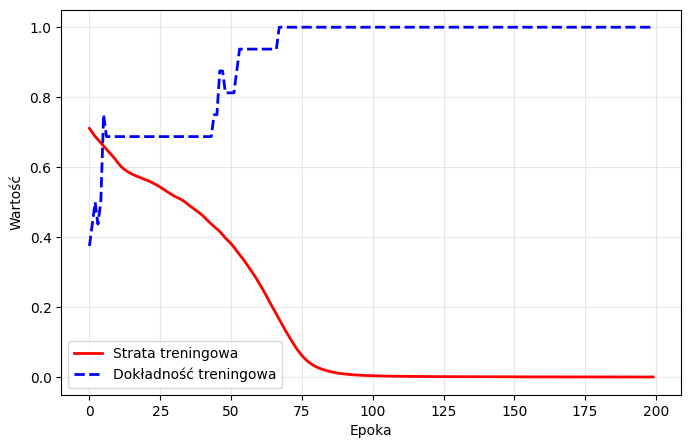

In [ ]:
INPUT_DIM = 23
model = BiGRUAttention(input_dim=INPUT_DIM, hidden_dim=16, dropout=0.0).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

X_batch, lengths_batch, y_batch = next(iter(train_loader))
X_batch, lengths_batch, y_batch = X_batch.to(device), lengths_batch.to(device), y_batch.to(device)

loss_history = []
acc_history = []

print(f"--- FEATURE ENGINEERED CHECK (Input Dim: {INPUT_DIM}) ---")

for i in range(200):
    opt.zero_grad()
    logits, _ = model(X_batch, lengths_batch)
    loss = criterion(logits, y_batch)
    loss.backward()
    opt.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        acc = (preds == y_batch).float().mean()

    loss_history.append(loss.item())
    acc_history.append(acc.item())
    
    if i % 50 == 0:
        print(f"Iter {i}: Loss {loss.item():.4f} | Acc {acc.item():.2f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Strata treningowa', color='red', linewidth=2)
plt.plot(acc_history, label='Dokładność treningowa', color='blue', linewidth=2, linestyle='--')

# plt.title('Overfit Check: Single Batch Convergence')
plt.xlabel('Epoka')
plt.ylabel('Wartość')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05) # Margines, żeby wykres nie dotykał krawędzi

# Zapis do pliku
save_path = "../docs/wut-thesis/images/overfit_check.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [28]:
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=True, reduce=True):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        if self.logits:
            bce_loss = self.bce(inputs, targets)
        else:
            bce_loss = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
        
        pt = torch.exp(-bce_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * bce_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss

In [15]:
NUM_EPOCHS = 60
model = BiGRUAttention(input_dim=23, hidden_dim=16, dropout=0.4).to(device)

init_bias = np.log(1/pos_weight.item())
with torch.no_grad():
    model.classifier[-1].bias.data.fill_(init_bias)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, verbose=True)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3
)
criterion = nn.BCEWithLogitsLoss()

history, thresh = train(model, optimizer, criterion, train_loader, val_loader, num_epochs=NUM_EPOCHS, scheduler=scheduler, early_stop=True, early_stop_patience=20, load_best_model=True, save_best_model_path="../model_weights/best_model_no_leakage.pt", scorer='auc')

Epoch 1: Loss=0.6276 | AUC=0.4701 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 2: Loss=0.6299 | AUC=0.4665 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 3: Loss=0.6299 | AUC=0.4865 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 4: Loss=0.6229 | AUC=0.4694 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 5: Loss=0.6287 | AUC=0.4715 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 6: Loss=0.6289 | AUC=0.4573 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 7: Loss=0.6323 | AUC=0.4480 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 8: Loss=0.6240 | AUC=0.4829 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 9: Loss=0.6217 | AUC=0.4679 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 10: Loss=0.6263 | AUC=0.4936 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 11: Loss=0.6244 | AUC=0.4922 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 12: Loss=0.6240 | AUC=0.4886 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 13: Loss=0.6214 | AUC=0.5299 | Best F1=0.806 (Thresh=0.10) | Acc=0.675
Epoch 14

Evaluating on test set with threshold 0.2899999999999999...

=== RESULTS ===
Accuracy:  0.6146
Precision: 0.6923
Recall:    0.8060
F1 Score:  0.7448
AUC ROC:   0.5234
------------------------------

Classification Report:
              precision    recall  f1-score   support

      Prawda     0.2778    0.1724    0.2128        29
    Kłamstwo     0.6923    0.8060    0.7448        67

    accuracy                         0.6146        96
   macro avg     0.4850    0.4892    0.4788        96
weighted avg     0.5671    0.6146    0.5841        96



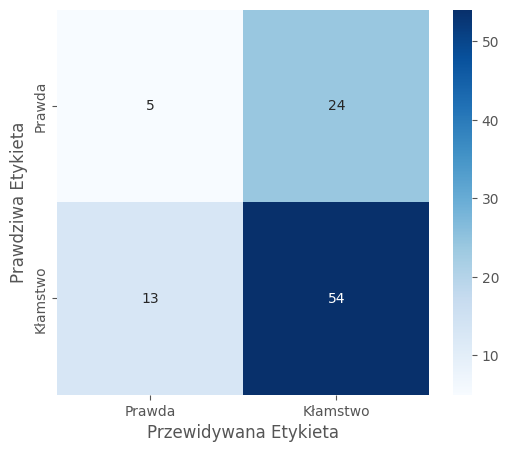

Zapisano: ../docs/wut-thesis/images/training_fixed_scaling/loss_curve.png
Zapisano: ../docs/wut-thesis/images/training_fixed_scaling/metrics_curve.png
Zapisano: ../docs/wut-thesis/images/training_fixed_scaling/threshold_curve.png


In [21]:
model = BiGRUAttention(input_dim=23, hidden_dim=16, dropout=0.4).to(device)
checkpoint = torch.load("../model_weights/best_model_no_leakage.pt")
model.load_state_dict(checkpoint['model_state_dict'])

all_labels, all_probs = evaluate_test_set(model, test_loader, device, threshold=thresh, class_names=['Prawda', 'Kłamstwo'], confusion_matrix_path='../docs/wut-thesis/images/training_fixed_scaling/confusion_matrix_test.png')

plot_learning_curves(history, save_dir="../docs/wut-thesis/images/training_fixed_scaling/")

In [84]:
print(model)

BiGRUAttention(
  (gru): GRU(23, 16, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attn): Attention(
    (attn): Linear(in_features=32, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)


Min Prob: 0.1045
Max Prob: 0.9896
Mean Prob: 0.6009
Std Dev:  0.2792


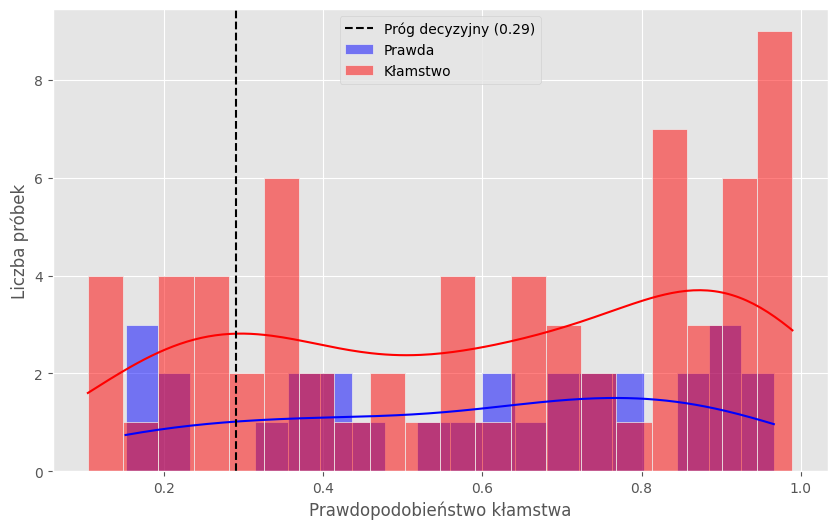

In [23]:
def probability_histogram(model, test_loader, device, threshold=0.5):
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X, lengths, y in test_loader:
            X, lengths, y = X.to(device), lengths.to(device), y.to(device)
            outputs = model(X, lengths)[0]
            probs = torch.sigmoid(outputs).squeeze()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    print(f"Min Prob: {all_probs.min():.4f}")
    print(f"Max Prob: {all_probs.max():.4f}")
    print(f"Mean Prob: {all_probs.mean():.4f}")
    print(f"Std Dev:  {all_probs.std():.4f}")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(all_probs[all_labels==0], color='blue', label='Prawda', kde=True, bins=20, alpha=0.5)
    sns.histplot(all_probs[all_labels==1], color='red', label='Kłamstwo', kde=True, bins=20, alpha=0.5)
    plt.axvline(x=threshold, color='k', linestyle='--', label=f'Próg decyzyjny ({threshold:.2f})')
    # plt.title('Rozkład prawdopodobieństw modelu na zbiorze testowym')
    plt.xlabel('Prawdopodobieństwo kłamstwa')
    plt.ylabel('Liczba próbek')
    plt.legend()
    plt.show()

    return all_probs, all_labels

checkpoint = torch.load("../model_weights/best_model_no_leakage.pt")
model.load_state_dict(checkpoint['model_state_dict'])
probs, labels = probability_histogram(model, test_loader, device, thresh)

# Transfer learning on different dataset

Real-Life Train: 20872
Real-Life Val:   4473
Real-Life Test:  4473


/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()



=== ZERO-SHOT EVALUATION (Before Fine-tuning) ===
Evaluating on test set with threshold 0.2899999999999999...

=== RESULTS ===
Accuracy:  0.4876
Precision: 0.4957
Recall:    0.9508
F1 Score:  0.6517
AUC ROC:   0.5276
------------------------------

Classification Report:
              precision    recall  f1-score   support

      Prawda     0.2500    0.0167    0.0312        60
    Kłamstwo     0.4957    0.9508    0.6517        61

    accuracy                         0.4876       121
   macro avg     0.3729    0.4837    0.3415       121
weighted avg     0.3739    0.4876    0.3440       121



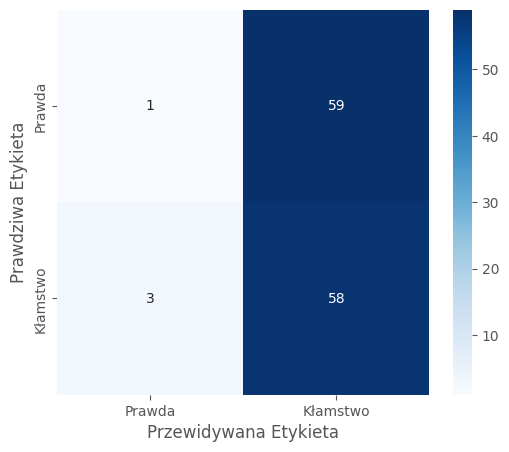

Calculated Initial Bias: 0.0165
Epoch 1: Loss=0.6893 | AUC=0.5036 | Best F1=0.670 (Thresh=0.10) | Acc=0.504
Epoch 2: Loss=0.6867 | AUC=0.5120 | Best F1=0.670 (Thresh=0.10) | Acc=0.504
Epoch 3: Loss=0.6931 | AUC=0.5301 | Best F1=0.674 (Thresh=0.47) | Acc=0.512
Epoch 4: Loss=0.6845 | AUC=0.5538 | Best F1=0.674 (Thresh=0.47) | Acc=0.512
Epoch 5: Loss=0.6837 | AUC=0.5730 | Best F1=0.674 (Thresh=0.47) | Acc=0.512
Epoch 6: Loss=0.6817 | AUC=0.5863 | Best F1=0.674 (Thresh=0.46) | Acc=0.512
Epoch 7: Loss=0.6812 | AUC=0.5973 | Best F1=0.674 (Thresh=0.46) | Acc=0.521
Epoch 8: Loss=0.6719 | AUC=0.6019 | Best F1=0.682 (Thresh=0.46) | Acc=0.545
Epoch 9: Loss=0.6738 | AUC=0.6161 | Best F1=0.682 (Thresh=0.44) | Acc=0.537
Epoch 10: Loss=0.6547 | AUC=0.6249 | Best F1=0.682 (Thresh=0.40) | Acc=0.537
Epoch 11: Loss=0.6558 | AUC=0.6388 | Best F1=0.689 (Thresh=0.34) | Acc=0.545
Epoch 12: Loss=0.6504 | AUC=0.6648 | Best F1=0.689 (Thresh=0.30) | Acc=0.545
Epoch 13: Loss=0.6294 | AUC=0.6678 | Best F1=0.689 (T

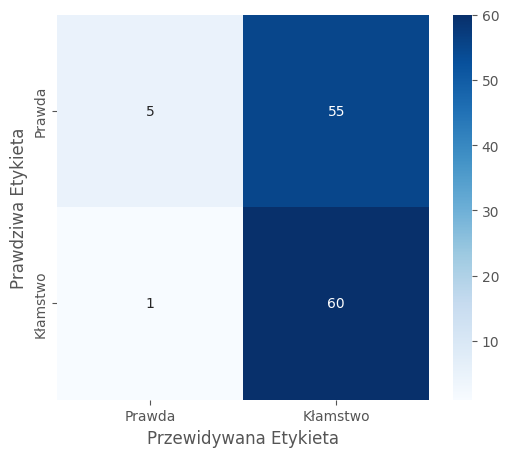

([0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0],
 [0.31015375,
  0.8129068,
  0.44791484,
  0.118948005,
  0.8405921,
  0.6632708,
  0.7051435,
  0.71499795,
  0.6114013,
  0.4942819,
  0.04228016,
  0

In [39]:
real_life_df = pd.read_csv("../processed_data/real_life_deception_detection_dataset/data10fps.csv")

rl_train_df, rl_temp_df = train_test_split(real_life_df, test_size=0.3, random_state=42, stratify=real_life_df['deceptive'])
rl_val_df, rl_test_df = train_test_split(rl_temp_df, test_size=0.5, random_state=42, stratify=rl_temp_df['deceptive'])

print(f"Real-Life Train: {len(rl_train_df)}")
print(f"Real-Life Val:   {len(rl_val_df)}")
print(f"Real-Life Test:  {len(rl_test_df)}")

for cols in [flow_cols, emotion_cols, head_pose_cols, box_cols]:
    scaler = scalers[cols[0]]
    rl_train_df[cols] = scaler.transform(rl_train_df[cols])
    rl_val_df[cols] = scaler.transform(rl_val_df[cols])
    rl_test_df[cols] = scaler.transform(rl_test_df[cols])

rl_train_dataset = FeatureEngineeredDataset(rl_train_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.05)
rl_val_dataset   = FeatureEngineeredDataset(rl_val_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)
rl_test_dataset  = FeatureEngineeredDataset(rl_test_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)

rl_train_loader = DataLoader(rl_train_dataset, batch_size=16, collate_fn=collate_fn, shuffle=True, drop_last=True)
rl_val_loader   = DataLoader(rl_val_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False)
rl_test_loader  = DataLoader(rl_test_dataset, batch_size=16, collate_fn=collate_fn, shuffle=False)

model = BiGRUAttention(input_dim=23, hidden_dim=16, dropout=0.4).to(device)

try:
    checkpoint = torch.load("../model_weights/best_model_no_leakage.pt")
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    threshold_silesian = checkpoint['threshold']
except FileNotFoundError:
    print("Error: Silesian weights not found.")

print("\n=== ZERO-SHOT EVALUATION (Before Fine-tuning) ===")
evaluate_test_set(
    model, 
    rl_test_loader, 
    device, 
    threshold=threshold_silesian,
    class_names=['Prawda', 'Kłamstwo'],
    confusion_matrix_path='../docs/wut-thesis/images/transfer_learning_scaled/confusion_matrix_real_life_test_zero_shot.png'
)

for param in model.parameters():
    param.requires_grad = False

# for param in model.classifier.parameters():
#     param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(16 * 2, 16),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(16, 1)
).to(device)

labels = [y.item() for _, y in rl_train_dataset]
n_pos = sum(labels)
n_neg = len(labels) - n_pos

initial_bias = np.log(n_pos / n_neg)
print(f"Calculated Initial Bias: {initial_bias:.4f}")

with torch.no_grad():
    model.classifier[-1].bias.data.fill_(initial_bias)

opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=0.02)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=1e-2,
    epochs=50,
    steps_per_epoch=len(rl_train_loader),
    pct_start=0.3
)

labels = [y.item() for _, y in rl_train_dataset]
n_pos = sum(labels)
n_neg = len(labels) - n_pos
pos_weight_rl = torch.tensor(n_neg / max(n_pos, 1)).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_rl)
history_rl, best_thresh_rl = train(
    model, 
    opt, 
    criterion, 
    rl_train_loader, 
    rl_val_loader,
    scheduler=scheduler,
    num_epochs=50, 
    early_stop=True,
    early_stop_patience=15,
    save_best_model_path="../model_weights/best_model_real_life_finetuned.pt",
    scorer="auc",
    load_best_model=True
)

plot_learning_curves(history_rl, save_dir="../docs/wut-thesis/images/transfer_learning_scaled/")

print("\n=== FINAL EVALUATION ON REAL-LIFE TEST SET ===")
evaluate_test_set(
    model, 
    rl_test_loader, 
    device, 
    threshold=best_thresh_rl,
    class_names=['Prawda', 'Kłamstwo'],
    confusion_matrix_path='../docs/wut-thesis/images/transfer_learning_scaled/confusion_matrix_real_life_test_finetuned.png'
)

Min Prob: 0.0149
Max Prob: 0.8673
Mean Prob: 0.5171
Std Dev:  0.1931


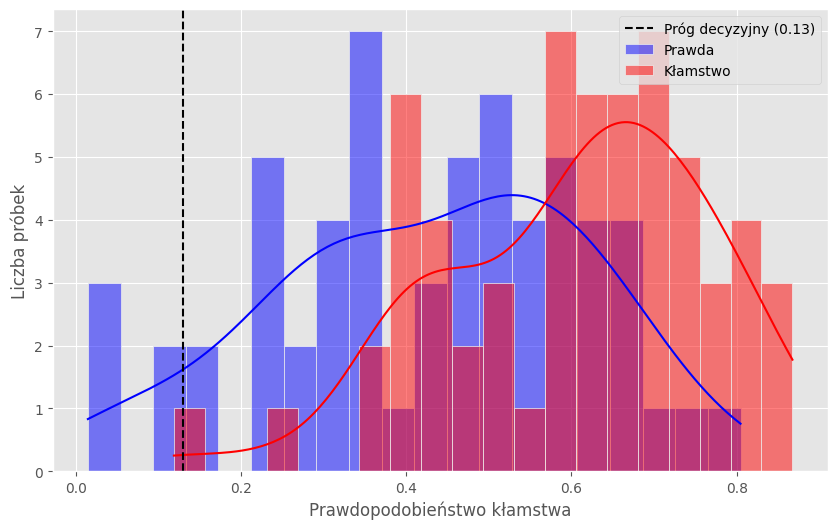

(array([0.31015375, 0.8129068 , 0.44791484, 0.11894801, 0.8405921 ,
        0.6632708 , 0.7051435 , 0.71499795, 0.6114013 , 0.4942819 ,
        0.04228016, 0.57895035, 0.6976167 , 0.64658034, 0.35377643,
        0.7461628 , 0.8419091 , 0.4857199 , 0.5739346 , 0.3241427 ,
        0.23322959, 0.4738941 , 0.52780277, 0.5625553 , 0.51531386,
        0.4356042 , 0.79645455, 0.33341363, 0.75863487, 0.1665477 ,
        0.44562215, 0.7416097 , 0.3799086 , 0.8046791 , 0.12486795,
        0.04002997, 0.6207063 , 0.530336  , 0.6055887 , 0.72973114,
        0.58015716, 0.6970803 , 0.53472215, 0.0148896 , 0.4910159 ,
        0.3623743 , 0.5106349 , 0.79159087, 0.63570565, 0.52260256,
        0.6504859 , 0.66862404, 0.41037273, 0.38309893, 0.43866453,
        0.48617616, 0.5908354 , 0.600372  , 0.5385507 , 0.71009606,
        0.69453955, 0.81348705, 0.69345117, 0.29675758, 0.31602952,
        0.630938  , 0.7665022 , 0.41766527, 0.43712395, 0.3832959 ,
        0.22927998, 0.86731166, 0.6727928 , 0.33

In [40]:
model = BiGRUAttention(input_dim=23, hidden_dim=16, dropout=0.5).to(device)
checkpoint = torch.load("../model_weights/best_model_real_life_finetuned.pt")
model.load_state_dict(checkpoint['model_state_dict'])
threshold = checkpoint['threshold']

probability_histogram(model, rl_test_loader, device, threshold)

In [41]:
print("\n--- CATASTROPHIC FORGETTING ANALYSIS (Impact on Silesian Dataset) ---")

silesian_test_dataset = FeatureEngineeredDataset(
    test_df,
    raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0
)
silesian_loader = DataLoader(silesian_test_dataset, batch_size=32, collate_fn=collate_fn, shuffle=False)

model_orig = BiGRUAttention(input_dim=23, hidden_dim=16, dropout=0.5).to(device)
ckpt_orig = torch.load("../model_weights/best_model_no_leakage.pt")
model_orig.load_state_dict(ckpt_orig['model_state_dict'])
thresh_orig = ckpt_orig.get('threshold', 0.5)

print("\n1. Original Model on Silesian:")
metrics_orig = evaluate(model_orig, silesian_loader)
print(f"AUC: {metrics_orig['auc']:.4f} | Acc: {metrics_orig['acc_at_best']:.3f} (Thresh={thresh_orig:.2f})")

print("\n2. Fine-Tuned Model on Silesian:")
metrics_tuned = evaluate(model, silesian_loader)
print(f"AUC: {metrics_tuned['auc']:.4f} | Acc: {metrics_tuned['acc_at_best']:.3f} (Thresh={best_thresh_rl:.2f})")

delta_auc = metrics_tuned['auc'] - metrics_orig['auc']
print(f"\nZmiana AUC na starym zbiorze: {delta_auc:+.4f}")
if delta_auc < -0.05:
    print("Wniosek: Wystąpiło 'Catastrophic Forgetting' (model zapomniał starą wiedzę).")
elif delta_auc > 0:
    print("Wniosek: 'Positive Transfer' (model działa lepiej nawet na starych danych!).")
else:
    print("Wniosek: Model zachował ogólną zdolność detekcji (stabilny).")


--- CATASTROPHIC FORGETTING ANALYSIS (Impact on Silesian Dataset) ---


/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()



1. Original Model on Silesian:
AUC: 0.5279 | Acc: 0.709 (Thresh=0.29)

2. Fine-Tuned Model on Silesian:
AUC: 0.4731 | Acc: 0.660 (Thresh=0.13)

Zmiana AUC na starym zbiorze: -0.0548
Wniosek: Wystąpiło 'Catastrophic Forgetting' (model zapomniał starą wiedzę).


# Purely emotion-based dataset analysis

In [ ]:
df = pd.read_csv("processed_data/silesian_deception_dataset/emotions.csv")
df.groupby("deceptive").mean()

,id,frame,Angry,Disgust,Fear,Happy,Sad,Surprise,Neutral
deceptive,,,,,,,,,
False,452.546502,3778.415965,0.130773,0.120608,0.121079,0.134827,0.148551,0.120610,0.223552
True,459.625536,6431.186514,0.129634,0.119907,0.120530,0.132197,0.152211,0.119913,0.225608


In [ ]:
df.groupby("deceptive").std()

,id,frame,Angry,Disgust,Fear,Happy,Sad,Surprise,Neutral
deceptive,,,,,,,,,
False,273.434383,3758.070614,0.040251,0.010359,0.012758,0.046865,0.060667,0.010363,0.085442
True,270.189444,2612.202414,0.039913,0.009980,0.013235,0.043731,0.064583,0.009990,0.085189


Minimal difference between truth/lie sequences. The model cannot learn anything, which is shown by the stable loss.

# Try different approach - Random Forest

/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()


Extracting statistics from 729 samples...


100%|██████████| 729/729 [00:01<00:00, 384.63it/s]


Extracting statistics from 103 samples...


100%|██████████| 103/103 [00:00<00:00, 402.75it/s]


Train Shape: (729, 92)
Test Shape: (103, 92)

--- Random Forest Results ---
Accuracy: 0.7184
F1 Score: 0.8343
AUC Score: 0.6393

--- Top 10 Most Important Features ---
1. Box_Center_Y_Mean: 0.0215
2. Mouth_V_Mean: 0.0200
3. Box_Width_Mean: 0.0189
4. flow_mean_y_Mean: 0.0183
5. Eye_R_Mean: 0.0168
6. flow_mean_x_Mean: 0.0164
7. Brow_R_Max: 0.0150
8. Mouth_H_Max: 0.0143
9. Box_Center_X_Mean: 0.0140
10. head_pitch_Mean: 0.0138


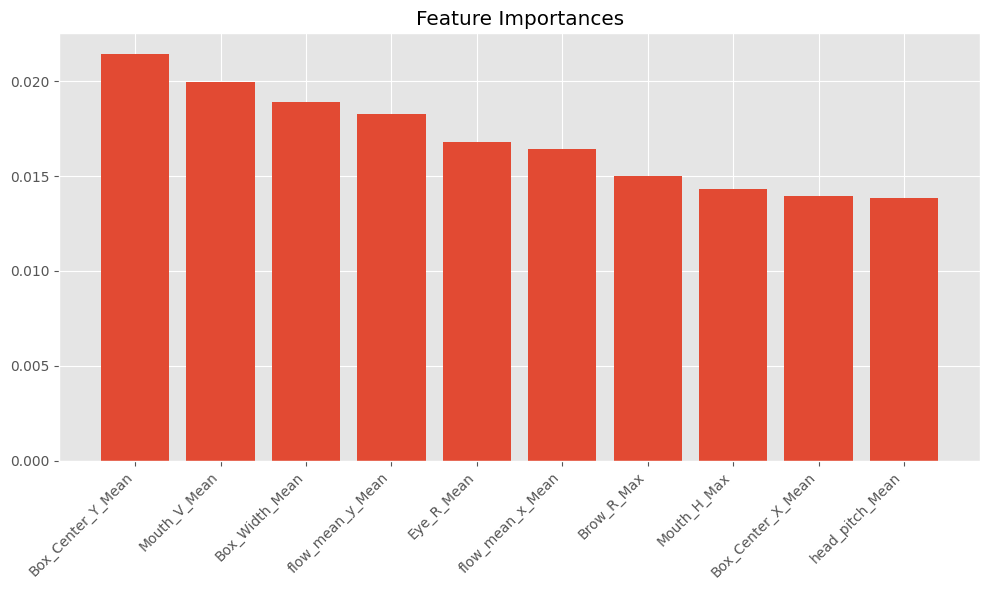

In [31]:
def extract_summary_stats(dataset):
    X_stats = []
    y_labels = []
    
    print(f"Extracting statistics from {len(dataset)} samples...")
    
    for i in tqdm(range(len(dataset))):
        X_seq, y = dataset[i]
        X_seq = X_seq.numpy()
        
        mu = np.mean(X_seq, axis=0)
        sigma = np.std(X_seq, axis=0)
        mx = np.max(X_seq, axis=0)
        rng = mx - np.min(X_seq, axis=0)
        
        sample_stats = np.concatenate([mu, sigma, mx, rng])
        
        X_stats.append(sample_stats)
        y_labels.append(y.item())
        
    return np.array(X_stats), np.array(y_labels)

train_dataset = FeatureEngineeredDataset(train_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)
test_dataset = FeatureEngineeredDataset(test_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)

X_train, y_train = extract_summary_stats(train_dataset)
X_test, y_test = extract_summary_stats(test_dataset)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print(f"\n--- Random Forest Results ---")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

feature_names = []
base_names = train_dataset.raw_cols + ['Mouth_V', 'Mouth_H', 'Eye_L', 'Eye_R', 'Brow_L', 'Brow_R', 'Box_Center_X', 'Box_Center_Y', 'Box_Width']
for stat in ['Mean', 'Std', 'Max', 'Range']:
    for name in base_names:
        feature_names.append(f"{name}_{stat}")

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Top 10 Most Important Features ---")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()
/tmp/ipykernel_5458/789569990.py:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill').fillna(0).rolling(window=5, min_periods=1).mean()


Extracting statistics from 121 samples...


100%|██████████| 121/121 [00:00<00:00, 253.38it/s]


Extracting statistics from 121 samples...


100%|██████████| 121/121 [00:00<00:00, 419.09it/s]


Train Shape: (121, 92)
Test Shape: (121, 92)

--- Random Forest Results ---
Accuracy: 0.7851
F1 Score: 0.7451
AUC Score: 0.9063

--- Top 10 Most Important Features ---
1. head_yaw_Max: 0.0350
2. head_yaw_Mean: 0.0308
3. head_yaw_Std: 0.0292
4. head_roll_Std: 0.0278
5. head_yaw_Range: 0.0275
6. head_roll_Range: 0.0275
7. Eye_R_Range: 0.0257
8. head_roll_Max: 0.0215
9. Brow_R_Mean: 0.0185
10. Mouth_V_Std: 0.0173


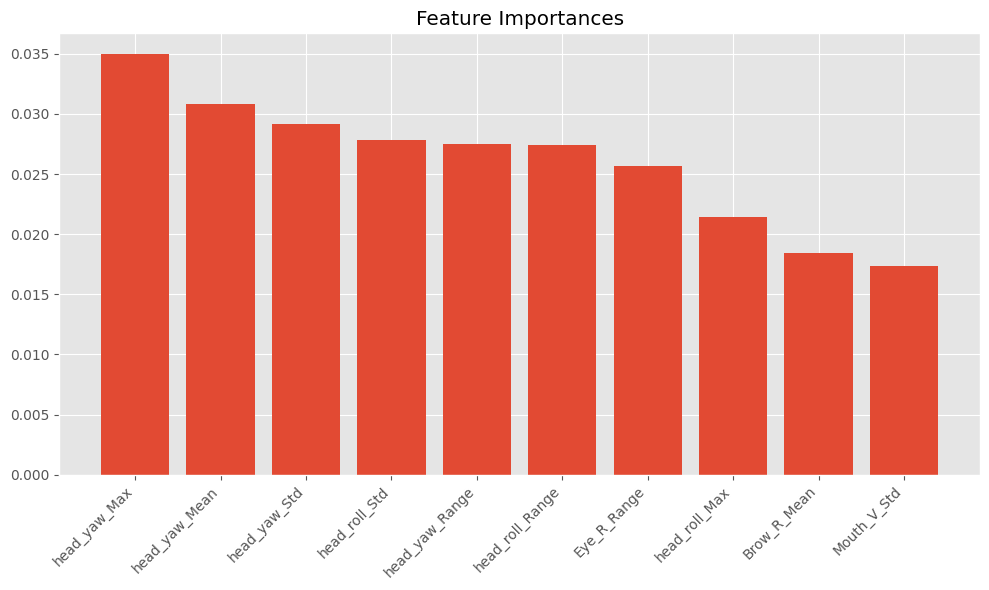

In [32]:
train_dataset = FeatureEngineeredDataset(rl_train_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)
test_dataset = FeatureEngineeredDataset(rl_test_df, raw_cols=raw_cols, use_distances=True, use_lm_velocity=False, use_box_velocity=True, noise_level=0.0)

X_train, y_train = extract_summary_stats(train_dataset)
X_test, y_test = extract_summary_stats(test_dataset)

print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print(f"\n--- Random Forest Results ---")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

feature_names = []
base_names = train_dataset.raw_cols + ['Mouth_V', 'Mouth_H', 'Eye_L', 'Eye_R', 'Brow_L', 'Brow_R', 'Box_Center_X', 'Box_Center_Y', 'Box_Width']
for stat in ['Mean', 'Std', 'Max', 'Range']:
    for name in base_names:
        feature_names.append(f"{name}_{stat}")

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Top 10 Most Important Features ---")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
# Sprawdzamy statystyki dla jednej przykładowej cechy po skalowaniu
col_name = flow_cols[0] # Jakaś pierwsza cecha
print(f"Cecha: {col_name}")
print(f"Min: {rl_train_df[col_name].min()}")
print(f"Max: {rl_train_df[col_name].max()}")
print(f"Mean: {rl_train_df[col_name].mean()}")

Cecha: flow_mean_x
Min: -0.7277467453011076
Max: 0.5866618938409526
Mean: 0.02107737084351733
